IndicCorp V2 — Sentence Tokenization + BPE / WordPiece Experiments
----------------------------------------------------------------------------
Designed to run on Kaggle (CPU is enough — the `tokenizers` library is
Rust-backed and trains a 1M-sentence / 50k-vocab BPE model in well under
a minute).
HOW TO USE ON KAGGLE
  1. Create a new Kaggle Notebook (Internet must be turned ON in
     Notebook settings > Internet, or the download cell will fail).
  2. Paste each "# %%" block below into its own cell (Kaggle/Jupyter
     recognise "# %%" as a cell marker), OR just paste the whole file
     into a single cell — it runs top to bottom either way.
  3. Change LANG_SPLIT in Cell 1 to your assigned language (see the
     list given there) and run all cells.
WHAT THIS SCRIPT DOES (maps directly to your assignment parts)
  Part 1: builds sentence-level train / dev(1000) / test(1000) splits
          from IndicCorpV2 paragraphs, with dev/test sampled so their
          sentence-length distribution mirrors the corpus (not a single
          length band) — see `stratified_sample_indices`.
  Part 2: trains BPE and WordPiece tokenizers (HuggingFace `tokenizers`)
          and tokenizes dev/test with each.
  Part 3: repeats training at 100k / 300k / 500k / 1,000,000 sentences
          (vocab size held fixed) and reports how tokenization changes.
  Part 4: repeats training at vocab sizes 20k / 30k / 50k (training size
          held fixed) and reports the impact of vocabulary size.

### Cell 0 — Install dependencies

In [1]:
# `datasets` is pinned because very new releases dropped some legacy loading
# paths; 2.19–2.20 reliably read this repo's plain data_files config.
!pip install -q "datasets==2.19.2" huggingface_hub tokenizers indic-nlp-library tqdm pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.1/542.1 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0/172.0 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 68.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.1/121.1 kB 8.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
tpot 1.1.0 requires dill>=0.3.9, but you have dill 0.3.8 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.3.1 which is incompatible.


### Cell 1 — Imports & configuration

In [2]:
import os, re, json, math, random
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

random.seed(42)
np.random.seed(42)

# ----------------------------------------------------------------------------
# CHOOSE YOUR LANGUAGE
# IndicCorpV2's HF config ("indiccorp_v2") exposes one *split* per language.
# Valid split names (copy exactly): 
#   asm_Beng, ben_Beng, brx_Deva, doi_Deva, gom_Deva, guj_Gujr, hin_Deva,
#   kan_Knda, kas_Arab, mai_Deva, mal_Mlym, mar_Deva, mni_Mtei, npi_Deva,
#   ory_Orya, pan_Guru, san_Deva, snd_Deva, tam_Taml, tel_Telu, urd_Arab,
#   khasi, santhali
# ----------------------------------------------------------------------------
LANG_SPLIT   = "tel_Telu"   # <-- matches your previous run
LANGUAGE_NAME = "Telugu"    # just used in plot titles / print statements
ISO_CODE     = "te"         # ISO code for indic-nlp sentence tokenizer;
                             # set to None to always use the regex fallback
                             # (Hindi=hi, Marathi=mr, Bengali=bn, Tamil=ta,
                             #  Telugu=te, Kannada=kn, Malayalam=ml,
                             #  Gujarati=gu, Punjabi=pa, Odia=or, Urdu=ur,
                             #  Nepali=ne, Sanskrit=sa, Assamese=as)

DEV_SIZE  = 1000
TEST_SIZE = 1000

TRAIN_SIZES = [100_000, 300_000, 500_000, 1_000_000]   # Part 3
VOCAB_SIZES = [20_000, 30_000, 50_000]                  # Part 4

FIXED_VOCAB_FOR_SIZE_STUDY  = 30_000     # vocab held constant while size varies
FIXED_TRAIN_FOR_VOCAB_STUDY = 500_000    # size held constant while vocab varies

# Buffer beyond the largest requirement so filtering/dedup doesn't leave us short
MIN_RAW_SENTENCES_NEEDED = max(TRAIN_SIZES) + DEV_SIZE + TEST_SIZE + 50_000

MIN_WORDS, MAX_WORDS = 3, 100   # sentence-length sanity filter

OUT_DIR = "/kaggle/working/indiccorp_experiment"
os.makedirs(OUT_DIR, exist_ok=True)

### Cell 2 — Stream raw paragraphs from IndicCorpV2 (no full download)

In [3]:
from datasets import load_dataset

def stream_raw_paragraphs(lang_split):
    """
    Streams text rows for `lang_split` without materialising the whole
    (multi-GB) file on disk or in RAM. Tries the documented split-based
    loading first, then falls back to the data_dir form some docs show.
    """
    last_err = None
    for kwargs in (
        dict(path="ai4bharat/IndicCorpV2", name="indiccorp_v2",
             split=lang_split, streaming=True),
        dict(path="ai4bharat/IndicCorpV2", name="indiccorp_v2",
             data_dir=f"data/{lang_split}", split="train", streaming=True),
    ):
        try:
            ds = load_dataset(**kwargs)
            for row in ds:
                text = row.get("text") or row.get("Text") or next(iter(row.values()))
                text = (text or "").strip()
                if text:
                    yield text
            return
        except Exception as e:
            last_err = e
            continue
    raise RuntimeError(
        f"Could not stream split '{lang_split}' from ai4bharat/IndicCorpV2. "
        f"Check the split name and that Internet is ON for this notebook. "
        f"Last error: {last_err}"
    )

### Cell 3 — Sentence tokenization (paragraph -> sentences)

In [4]:
try:
    from indicnlp.tokenize import sentence_tokenize
    INDIC_NLP_AVAILABLE = True
except ImportError:
    INDIC_NLP_AVAILABLE = False
    print("indic-nlp-library not available, using regex sentence splitter only.")

# Regex fallback: split after Indic danda (।), double danda (॥), or . ! ?
_SENT_END_RE = re.compile(r'(?<=[।॥.!?])\s+')

def split_sentences(paragraph, iso_code=ISO_CODE):
    if INDIC_NLP_AVAILABLE and iso_code:
        try:
            sents = sentence_tokenize.sentence_split(paragraph, lang=iso_code)
            sents = [s.strip() for s in sents if s.strip()]
            if sents:
                return sents
        except Exception:
            pass
    return [s.strip() for s in _SENT_END_RE.split(paragraph) if s.strip()]

def word_count(s):
    return len(s.split())

### Cell 4 — Build the sentence corpus (streaming, deduped, length-filtered)

In [5]:
def build_sentence_corpus(lang_split, target_count):
    seen = set()
    sentences = []
    pbar = tqdm(total=target_count, desc="Collecting sentences")
    for para in stream_raw_paragraphs(lang_split):
        for sent in split_sentences(para):
            wc = word_count(sent)
            if wc < MIN_WORDS or wc > MAX_WORDS:
                continue
            if sent in seen:
                continue
            seen.add(sent)
            sentences.append(sent)
            pbar.update(1)
            if len(sentences) >= target_count:
                pbar.close()
                return sentences
    pbar.close()
    print(f"WARNING: corpus exhausted early with only {len(sentences)} sentences "
          f"(needed {target_count}). Lower TRAIN_SIZES/MIN_WORDS if this happens.")
    return sentences

all_sentences = build_sentence_corpus(LANG_SPLIT, MIN_RAW_SENTENCES_NEEDED)
print(f"Collected {len(all_sentences)} unique sentences for {LANGUAGE_NAME}")

assert len(all_sentences) >= max(TRAIN_SIZES) + DEV_SIZE + TEST_SIZE, (
    "Not enough sentences collected — increase MIN_RAW_SENTENCES_NEEDED buffer "
    "or reduce TRAIN_SIZES."
)

Collected 1052000 unique sentences for Telugu


### Cell 5 — Length distribution + length-stratified dev/test sampling

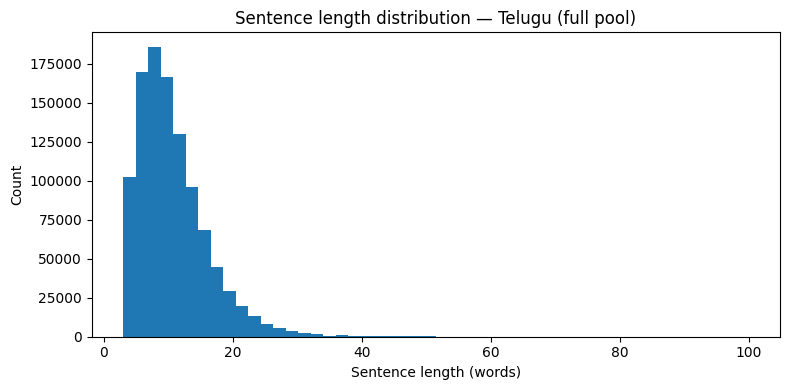

Train pool: 1050000 | Dev: 1000 | Test: 1000
Full   -> mean=10.5  std=5.8  min=3  p25=6  median=9  p75=13  max=100
Dev    -> mean=10.5  std=5.8  min=3  p25=6  median=9  p75=13  max=51
Test   -> mean=10.5  std=5.7  min=3  p25=6  median=9  p75=13  max=52


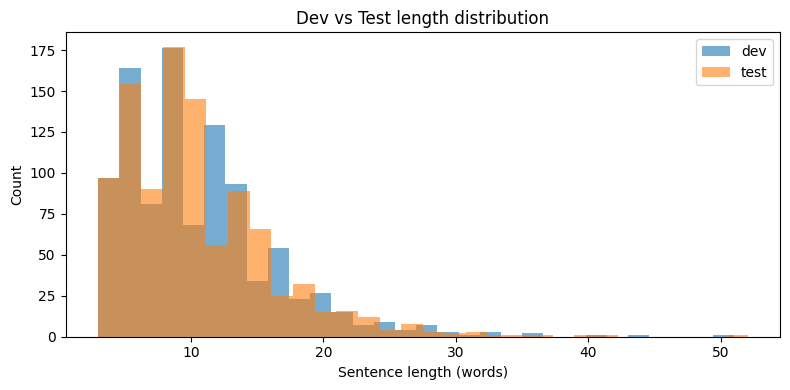

In [6]:
lengths = np.array([word_count(s) for s in all_sentences])

plt.figure(figsize=(8, 4))
plt.hist(lengths, bins=50)
plt.title(f"Sentence length distribution — {LANGUAGE_NAME} (full pool)")
plt.xlabel("Sentence length (words)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "length_distribution_full.png"))
plt.show()

BIN_EDGES = [0, 5, 10, 15, 20, 25, 30, 40, 50, 70, 100, 1000]

def make_length_bins(lengths, bin_edges=BIN_EDGES):
    return np.digitize(lengths, bin_edges)

bin_ids = make_length_bins(lengths)

def stratified_sample_indices(bin_ids, n_total, exclude=None):
    """
    Samples n_total indices such that the *proportion* taken from each
    length bin matches that bin's share of the overall pool. This is what
    guarantees dev/test aren't dominated by one narrow length range, while
    still reflecting the real distribution (per the assignment hint).
    """
    exclude = exclude or set()
    by_bin = defaultdict(list)
    for idx, b in enumerate(bin_ids):
        if idx in exclude:
            continue
        by_bin[b].append(idx)

    total_pool = sum(len(v) for v in by_bin.values())
    raw_alloc = {b: len(v) / total_pool * n_total for b, v in by_bin.items()}
    alloc = {b: int(math.floor(v)) for b, v in raw_alloc.items()}
    remainder = n_total - sum(alloc.values())

    # largest-remainder method to hit exactly n_total
    fracs = sorted(raw_alloc.items(), key=lambda kv: (kv[1] - math.floor(kv[1])), reverse=True)
    i = 0
    while remainder > 0 and i < len(fracs):
        b = fracs[i][0]
        if alloc[b] < len(by_bin[b]):
            alloc[b] += 1
            remainder -= 1
        i += 1

    selected = []
    for b, count in alloc.items():
        pool = by_bin[b]
        count = min(count, len(pool))
        selected.extend(random.sample(pool, count))
    random.shuffle(selected)
    return set(selected)

dev_idx  = stratified_sample_indices(bin_ids, DEV_SIZE)
test_idx = stratified_sample_indices(bin_ids, TEST_SIZE, exclude=dev_idx)

dev_sentences  = [all_sentences[i] for i in dev_idx]
test_sentences = [all_sentences[i] for i in test_idx]

train_pool_idx = [i for i in range(len(all_sentences)) if i not in dev_idx and i not in test_idx]
train_pool = [all_sentences[i] for i in train_pool_idx]
random.shuffle(train_pool)   # shuffle ONCE so size-prefixes below are nested/comparable

print(f"Train pool: {len(train_pool)} | Dev: {len(dev_sentences)} | Test: {len(test_sentences)}")

# Sanity check: dev/test length distribution should track the full pool,
# not cluster on one length band.
def summarize_lengths(name, sents):
    L = np.array([word_count(s) for s in sents])
    print(f"{name:6s} -> mean={L.mean():.1f}  std={L.std():.1f}  "
          f"min={L.min()}  p25={np.percentile(L,25):.0f}  "
          f"median={np.median(L):.0f}  p75={np.percentile(L,75):.0f}  max={L.max()}")

summarize_lengths("Full", all_sentences)
summarize_lengths("Dev",  dev_sentences)
summarize_lengths("Test", test_sentences)

plt.figure(figsize=(8, 4))
plt.hist([word_count(s) for s in dev_sentences], bins=30, alpha=0.6, label="dev")
plt.hist([word_count(s) for s in test_sentences], bins=30, alpha=0.6, label="test")
plt.legend(); plt.title("Dev vs Test length distribution")
plt.xlabel("Sentence length (words)"); plt.ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "dev_test_length_distribution.png"))
plt.show()

### Cell 6 — Save splits to disk

In [7]:
def save_lines(path, lines):
    with open(path, "w", encoding="utf-8") as f:
        for l in lines:
            f.write(l.replace("\n", " ").strip() + "\n")

save_lines(os.path.join(OUT_DIR, "dev.txt"),  dev_sentences)
save_lines(os.path.join(OUT_DIR, "test.txt"), test_sentences)
save_lines(os.path.join(OUT_DIR, "train_pool_full.txt"), train_pool)

# Nested training subsets (each smaller size is a prefix of the larger ones,
# so size comparisons in Part 3 aren't confounded by different content)
train_subsets = {}
for size in TRAIN_SIZES:
    subset = train_pool[:size]
    train_subsets[size] = subset
    save_lines(os.path.join(OUT_DIR, f"train_{size}.txt"), subset)
    print(f"train_{size}: {len(subset)} sentences saved")

train_100000: 100000 sentences saved
train_300000: 300000 sentences saved
train_500000: 500000 sentences saved
train_1000000: 1000000 sentences saved


### Cell 7 — Tokenizer training functions (BPE & WordPiece)

In [8]:
from tokenizers import Tokenizer, models, trainers, pre_tokenizers, normalizers, decoders

SPECIAL_TOKENS = ["[UNK]", "[PAD]", "[CLS]", "[SEP]", "[MASK]"]

def train_bpe(sentences, vocab_size, save_path=None):
    tok = Tokenizer(models.BPE(unk_token="[UNK]"))
    tok.normalizer = normalizers.NFKC()
    tok.pre_tokenizer = pre_tokenizers.Whitespace()
    trainer = trainers.BpeTrainer(
        vocab_size=vocab_size, special_tokens=SPECIAL_TOKENS, min_frequency=2,
    )
    tok.train_from_iterator(sentences, trainer=trainer)
    tok.decoder = decoders.BPEDecoder()
    if save_path:
        tok.save(save_path)
    return tok

def train_wordpiece(sentences, vocab_size, save_path=None):
    tok = Tokenizer(models.WordPiece(unk_token="[UNK]"))
    tok.normalizer = normalizers.NFKC()
    tok.pre_tokenizer = pre_tokenizers.Whitespace()
    trainer = trainers.WordPieceTrainer(
        vocab_size=vocab_size, special_tokens=SPECIAL_TOKENS, min_frequency=2,
    )
    tok.train_from_iterator(sentences, trainer=trainer)
    tok.decoder = decoders.WordPiece()
    if save_path:
        tok.save(save_path)
    return tok

### Cell 8 — Evaluation utilities

In [9]:
def evaluate_tokenizer(tok, sentences):
    total_tokens = total_chars = total_words = unk_count = 0
    unk_id = tok.token_to_id("[UNK]")
    for s in sentences:
        ids = tok.encode(s).ids
        total_tokens += len(ids)
        total_chars  += len(s)
        total_words  += len(s.split())
        unk_count    += sum(1 for i in ids if i == unk_id)
    return {
        "n_sentences": len(sentences),
        "avg_tokens_per_sentence": total_tokens / len(sentences),
        "avg_tokens_per_word": total_tokens / total_words,
        "chars_per_token": total_chars / total_tokens,
        "unk_rate_%": 100 * unk_count / total_tokens,
        "vocab_size": tok.get_vocab_size(),
    }

def save_tokenized(tok, sentences, path):
    with open(path, "w", encoding="utf-8") as f:
        for s in sentences:
            f.write(" ".join(tok.encode(s).tokens) + "\n")

### Cell 9 — PART 3: vary training-data SIZE, vocab fixed

In [10]:
results_size_study = {"bpe": {}, "wordpiece": {}}

for size in TRAIN_SIZES:
    sents = train_subsets[size]
    print(f"\n=== Training size = {size} (vocab={FIXED_VOCAB_FOR_SIZE_STUDY}) ===")

    bpe_tok = train_bpe(sents, FIXED_VOCAB_FOR_SIZE_STUDY,
                         save_path=os.path.join(OUT_DIR, f"bpe_size{size}.json"))
    wp_tok  = train_wordpiece(sents, FIXED_VOCAB_FOR_SIZE_STUDY,
                         save_path=os.path.join(OUT_DIR, f"wp_size{size}.json"))

    results_size_study["bpe"][size] = {
        "dev":  evaluate_tokenizer(bpe_tok, dev_sentences),
        "test": evaluate_tokenizer(bpe_tok, test_sentences),
    }
    results_size_study["wordpiece"][size] = {
        "dev":  evaluate_tokenizer(wp_tok, dev_sentences),
        "test": evaluate_tokenizer(wp_tok, test_sentences),
    }

    save_tokenized(bpe_tok, dev_sentences,  os.path.join(OUT_DIR, f"dev_bpe_size{size}.txt"))
    save_tokenized(bpe_tok, test_sentences, os.path.join(OUT_DIR, f"test_bpe_size{size}.txt"))
    save_tokenized(wp_tok,  dev_sentences,  os.path.join(OUT_DIR, f"dev_wp_size{size}.txt"))
    save_tokenized(wp_tok,  test_sentences, os.path.join(OUT_DIR, f"test_wp_size{size}.txt"))

    print(f"  BPE       dev avg tokens/sentence = "
          f"{results_size_study['bpe'][size]['dev']['avg_tokens_per_sentence']:.2f}")
    print(f"  WordPiece dev avg tokens/sentence = "
          f"{results_size_study['wordpiece'][size]['dev']['avg_tokens_per_sentence']:.2f}")


=== Training size = 100000 (vocab=30000) ===






  BPE       dev avg tokens/sentence = 15.74
  WordPiece dev avg tokens/sentence = 16.09

=== Training size = 300000 (vocab=30000) ===






  BPE       dev avg tokens/sentence = 15.66
  WordPiece dev avg tokens/sentence = 16.04

=== Training size = 500000 (vocab=30000) ===






  BPE       dev avg tokens/sentence = 15.66
  WordPiece dev avg tokens/sentence = 16.03

=== Training size = 1000000 (vocab=30000) ===






  BPE       dev avg tokens/sentence = 15.63
  WordPiece dev avg tokens/sentence = 16.07


### Cell 10 — PART 4: vary VOCAB size, training size fixed

In [11]:
fixed_train_sents = train_subsets[FIXED_TRAIN_FOR_VOCAB_STUDY]
results_vocab_study = {"bpe": {}, "wordpiece": {}}

for vs in VOCAB_SIZES:
    print(f"\n=== Vocab size = {vs} (train_size={FIXED_TRAIN_FOR_VOCAB_STUDY}) ===")

    bpe_tok = train_bpe(fixed_train_sents, vs,
                         save_path=os.path.join(OUT_DIR, f"bpe_vocab{vs}.json"))
    wp_tok  = train_wordpiece(fixed_train_sents, vs,
                         save_path=os.path.join(OUT_DIR, f"wp_vocab{vs}.json"))

    results_vocab_study["bpe"][vs] = {
        "dev":  evaluate_tokenizer(bpe_tok, dev_sentences),
        "test": evaluate_tokenizer(bpe_tok, test_sentences),
    }
    results_vocab_study["wordpiece"][vs] = {
        "dev":  evaluate_tokenizer(wp_tok, dev_sentences),
        "test": evaluate_tokenizer(wp_tok, test_sentences),
    }

    save_tokenized(bpe_tok, dev_sentences,  os.path.join(OUT_DIR, f"dev_bpe_vocab{vs}.txt"))
    save_tokenized(bpe_tok, test_sentences, os.path.join(OUT_DIR, f"test_bpe_vocab{vs}.txt"))
    save_tokenized(wp_tok,  dev_sentences,  os.path.join(OUT_DIR, f"dev_wp_vocab{vs}.txt"))
    save_tokenized(wp_tok,  test_sentences, os.path.join(OUT_DIR, f"test_wp_vocab{vs}.txt"))

    print(f"  BPE       dev avg tokens/sentence = "
          f"{results_vocab_study['bpe'][vs]['dev']['avg_tokens_per_sentence']:.2f}")
    print(f"  WordPiece dev avg tokens/sentence = "
          f"{results_vocab_study['wordpiece'][vs]['dev']['avg_tokens_per_sentence']:.2f}")


=== Vocab size = 20000 (train_size=500000) ===






  BPE       dev avg tokens/sentence = 16.55
  WordPiece dev avg tokens/sentence = 17.10

=== Vocab size = 30000 (train_size=500000) ===






  BPE       dev avg tokens/sentence = 15.66
  WordPiece dev avg tokens/sentence = 16.03

=== Vocab size = 50000 (train_size=500000) ===






  BPE       dev avg tokens/sentence = 14.77
  WordPiece dev avg tokens/sentence = 15.03


### Cell 11 — Tabulate + save results

In [12]:
def flatten_results(results, x_label):
    rows = []
    for algo, per_x in results.items():
        for x, splits in per_x.items():
            for split_name, metrics in splits.items():
                row = {"algorithm": algo, x_label: x, "split": split_name}
                row.update(metrics)
                rows.append(row)
    return pd.DataFrame(rows)

df_size  = flatten_results(results_size_study,  "train_size")
df_vocab = flatten_results(results_vocab_study, "vocab_size")

df_size.to_csv(os.path.join(OUT_DIR, "results_train_size_study.csv"), index=False)
df_vocab.to_csv(os.path.join(OUT_DIR, "results_vocab_size_study.csv"), index=False)

with open(os.path.join(OUT_DIR, "results_all.json"), "w") as f:
    json.dump({"size_study": results_size_study, "vocab_study": results_vocab_study}, f, indent=2)

print("\n=== Training-size study (test split) ===")
print(df_size[df_size.split == "test"].sort_values(["algorithm", "train_size"])
      .to_string(index=False))

print("\n=== Vocab-size study (test split) ===")
print(df_vocab[df_vocab.split == "test"].sort_values(["algorithm", "vocab_size"])
      .to_string(index=False))


=== Training-size study (test split) ===
algorithm  train_size split  n_sentences  avg_tokens_per_sentence  avg_tokens_per_word  chars_per_token  unk_rate_%  vocab_size
      bpe      100000  test         1000                   15.842             1.514242         5.171885         0.0       30000
      bpe      300000  test         1000                   15.809             1.511088         5.182681         0.0       30000
      bpe      500000  test         1000                   15.831             1.513191         5.175478         0.0       30000
      bpe     1000000  test         1000                   15.816             1.511757         5.180387         0.0       30000
wordpiece      100000  test         1000                   16.298             1.557828         5.027181         0.0       30000
wordpiece      300000  test         1000                   16.240             1.552284         5.045135         0.0       30000
wordpiece      500000  test         1000                   16.

### Cell 12 — Plots

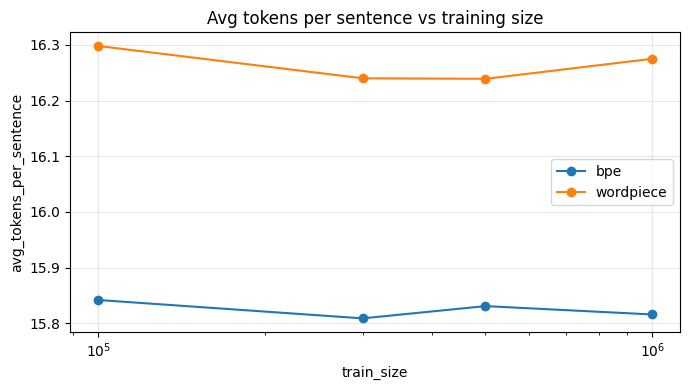

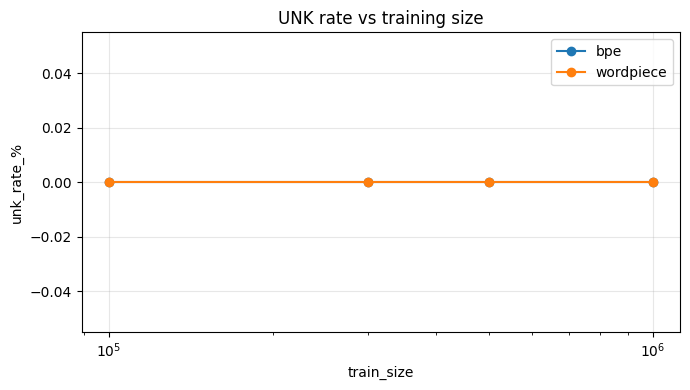

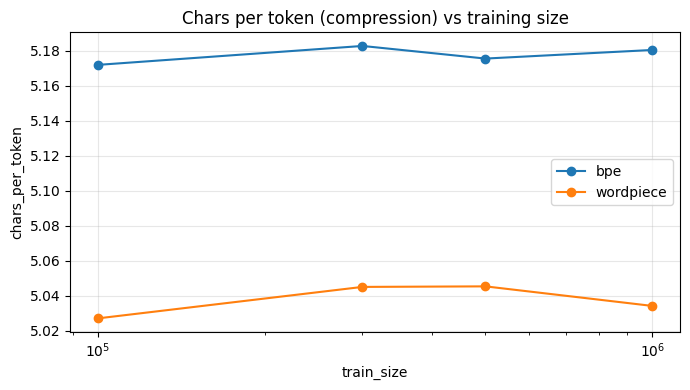

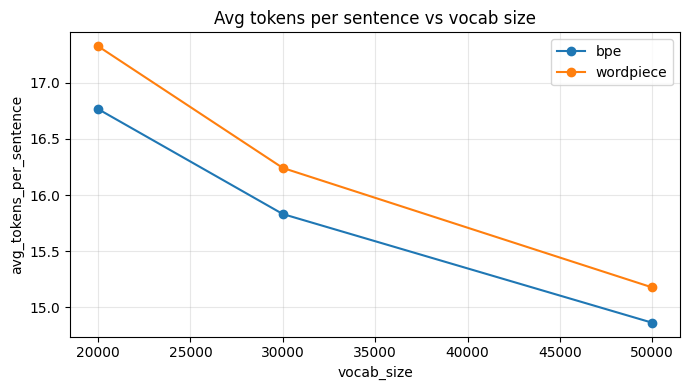

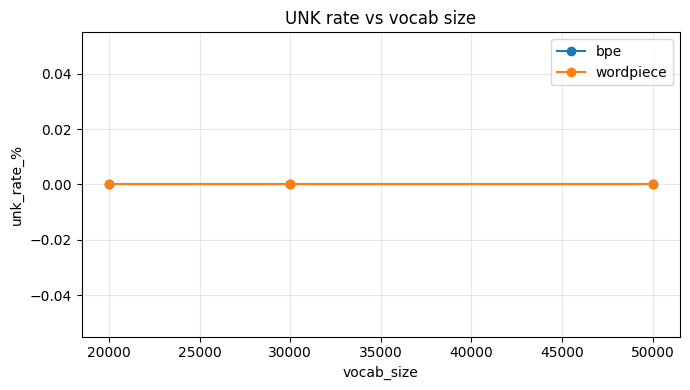

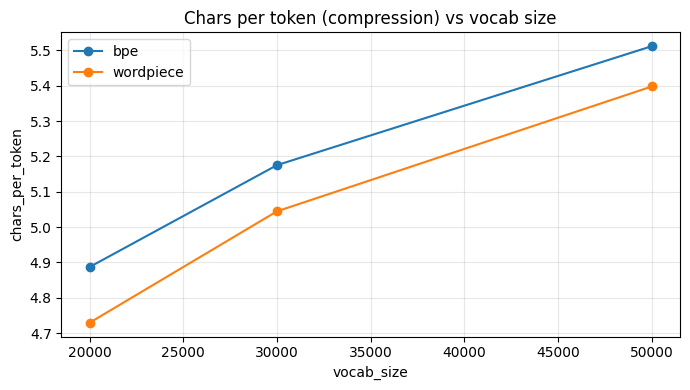

In [13]:
def plot_metric_vs_x(df, x_col, metric, title, logx=False):
    plt.figure(figsize=(7, 4))
    for algo in df["algorithm"].unique():
        sub = df[(df.algorithm == algo) & (df.split == "test")].sort_values(x_col)
        plt.plot(sub[x_col], sub[metric], marker="o", label=algo)
    if logx:
        plt.xscale("log")
    plt.xlabel(x_col); plt.ylabel(metric); plt.title(title)
    plt.legend(); plt.grid(alpha=0.3)
    plt.tight_layout()
    fname = title.lower().replace(" ", "_").replace("/", "_") + ".png"
    plt.savefig(os.path.join(OUT_DIR, fname))
    plt.show()

plot_metric_vs_x(df_size,  "train_size", "avg_tokens_per_sentence",
                  "Avg tokens per sentence vs training size", logx=True)
plot_metric_vs_x(df_size,  "train_size", "unk_rate_%",
                  "UNK rate vs training size", logx=True)
plot_metric_vs_x(df_size,  "train_size", "chars_per_token",
                  "Chars per token (compression) vs training size", logx=True)

plot_metric_vs_x(df_vocab, "vocab_size", "avg_tokens_per_sentence",
                  "Avg tokens per sentence vs vocab size")
plot_metric_vs_x(df_vocab, "vocab_size", "unk_rate_%",
                  "UNK rate vs vocab size")
plot_metric_vs_x(df_vocab, "vocab_size", "chars_per_token",
                  "Chars per token (compression) vs vocab size")

### Cell 13 — Qualitative comparison: same sentences, different tokenizers

In [14]:
sample_sentences = dev_sentences[:5]

def show_tokenizations(sentences, tok, name):
    print(f"\n--- {name} ---")
    for s in sentences:
        print(f"SRC: {s}")
        print(f"TOK: {tok.encode(s).tokens}\n")

best_bpe = train_bpe(train_subsets[FIXED_TRAIN_FOR_VOCAB_STUDY], 30_000)
best_wp  = train_wordpiece(train_subsets[FIXED_TRAIN_FOR_VOCAB_STUDY], 30_000)

show_tokenizations(sample_sentences, best_bpe, "BPE (train=500k, vocab=30k)")
show_tokenizations(sample_sentences, best_wp,  "WordPiece (train=500k, vocab=30k)")

print(f"\nAll outputs (splits, tokenizer files, tokenized dev/test, CSVs, plots) "
      f"saved under: {OUT_DIR}")








--- BPE (train=500k, vocab=30k) ---
SRC: తాజాగా ఇజిన్‌ అనే కౌంటీలో కరోనా డెల్టా వేరియంట్‌ ప్రబలింది.
TOK: ['తాజాగా', 'ఇ', 'జిన్\u200c', 'అనే', 'కౌంటీ', 'లో', 'కరోనా', 'డెల్టా', 'వేరియంట్\u200c', 'ప్ర', 'బలి', 'ంది', '.']

SRC: నాలుగువేల కోట్ల విలువైన పనులను ‘ట్రాన్స్‌ట్రాయ్’కి అప్పగించారు.
TOK: ['నాలుగు', 'వేల', 'కోట్ల', 'విలువైన', 'పనులను', '‘', 'ట్రాన్స్\u200c', 'ట్రాయ్', '’', 'కి', 'అప్పగించారు', '.']

SRC: గెట్‌ రెడీ. . మూడొంతుల ఓట్లు మనకే రావాలె
TOK: ['గె', 'ట్\u200c', 'రెడీ', '.', '.', 'మూ', 'డొ', 'ం', 'తుల', 'ఓట్లు', 'మన', 'కే', 'రావ', 'ాలె']

SRC: ఆయా ప్రాంతాల స్వభావం, సామాజిక పరిస్థితులకు అనుగుణంగా ప్రభుత్వ శాఖల విభాగాలు ఏర్పాటు చేయాలన్నారు.
TOK: ['ఆయా', 'ప్రాంతాల', 'స్వభావం', ',', 'సామాజిక', 'పరిస్థితులకు', 'అనుగుణంగా', 'ప్రభుత్వ', 'శాఖల', 'విభాగాలు', 'ఏర్పాటు', 'చేయాలన్నారు', '.']

SRC: మరియు అన్ని సమస్యలను పరిష్కరించటానికి, చాలా, చాలా ఉంటుంది.
TOK: ['మరియు', 'అన్ని', 'సమస్యలను', 'పరిష్కరి', 'ంచటానికి', ',', 'చాలా', ',', 'చాలా', 'ఉంటుంది', '.']


--- WordPiece (train=

---
# PART 2 — N-gram Language Models with Smoothing
Everything above this point builds the corpus and the BPE/WordPiece tokenizers (Assignment: tokenization). Everything below reuses the exact same `train_1000000.txt` / `dev.txt` / `test.txt` already sitting in memory and on disk from Part 1 above, and builds the unigram-to-quadgram language models with 5 smoothing methods.

**Note:** the config cell just below re-sets a few variables (`MIN_COUNT`, `N_ORDERS`, `DISCOUNT_D`, etc.) that only this part needs — this is expected and safe to run right after Part 1.

### Cell 1 — Config

In [15]:
import os, re, json, math, random
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

random.seed(42)
np.random.seed(42)

# Must match the previous assignment exactly so splits reproduce if rebuilt
LANG_SPLIT    = "tel_Telu"
LANGUAGE_NAME = "Telugu"
ISO_CODE      = "te"

DEV_SIZE, TEST_SIZE = 1000, 1000
TRAIN_SIZES = [100_000, 300_000, 500_000, 1_000_000]
MIN_WORDS, MAX_WORDS = 3, 100
MIN_RAW_SENTENCES_NEEDED = max(TRAIN_SIZES) + DEV_SIZE + TEST_SIZE + 50_000

OUT_DIR = "/kaggle/working/indiccorp_experiment"
os.makedirs(OUT_DIR, exist_ok=True)

# --- This assignment's own settings -----------------------------------------
LM_TRAIN_SENTENCES = 1_000_000   # "same corpus containing a total of 1,000,000
                                  # sentences" as required. NOTE: quadgram
                                  # counting over the full 1M sentences can use
                                  # several GB of RAM. If Kaggle's kernel dies
                                  # with an OOM, lower this to e.g. 300_000 —
                                  # everything below still runs unchanged.
N_ORDERS   = [1, 2, 3, 4]        # unigram .. quadgram
DISCOUNT_D = 0.75                # Kneser-Ney discount (fixed, as specified)
MIN_COUNT  = 5                   # words rarer than this in train -> <unk>
                                  # (keeps vocab size, and quadgram memory,
                                  # under control on a morphologically rich
                                  # language; standard practice for word-LMs)

ADDK_GRID   = [round(x, 3) for x in np.arange(0.01, 1.0, 0.03)]
LAMBDA_GRID = [round(x, 2) for x in np.arange(0.05, 1.0, 0.05)]

BOS, EOS, UNK = "<s>", "</s>", "<unk>"

### Cell 2 — Load train/dev/test (reuse if present, else rebuild identically)

In [16]:
train_path = os.path.join(OUT_DIR, f"train_{LM_TRAIN_SENTENCES}.txt")
dev_path   = os.path.join(OUT_DIR, "dev.txt")
test_path  = os.path.join(OUT_DIR, "test.txt")

def read_lines(path):
    with open(path, encoding="utf-8") as f:
        return [l.rstrip("\n") for l in f]

if os.path.exists(train_path) and os.path.exists(dev_path) and os.path.exists(test_path):
    print("Found existing splits on disk — loading them directly.")
    train_sentences = read_lines(train_path)
    dev_sentences   = read_lines(dev_path)
    test_sentences  = read_lines(test_path)
else:
    print("Splits not found in this session — rebuilding from scratch "
          "(same LANG_SPLIT + same seed => identical split to before).")
    from datasets import load_dataset

    def stream_raw_paragraphs(lang_split):
        last_err = None
        for kwargs in (
            dict(path="ai4bharat/IndicCorpV2", name="indiccorp_v2", split=lang_split, streaming=True),
            dict(path="ai4bharat/IndicCorpV2", name="indiccorp_v2", data_dir=f"data/{lang_split}", split="train", streaming=True),
        ):
            try:
                ds = load_dataset(**kwargs)
                for row in ds:
                    text = (row.get("text") or row.get("Text") or next(iter(row.values())) or "").strip()
                    if text:
                        yield text
                return
            except Exception as e:
                last_err = e
        raise RuntimeError(f"Could not stream split '{lang_split}': {last_err}")

    try:
        from indicnlp.tokenize import sentence_tokenize
        INDIC_NLP_AVAILABLE = True
    except ImportError:
        INDIC_NLP_AVAILABLE = False

    _SENT_END_RE = re.compile(r'(?<=[।॥.!?])\s+')

    def split_sentences(paragraph, iso_code=ISO_CODE):
        if INDIC_NLP_AVAILABLE and iso_code:
            try:
                sents = [s.strip() for s in sentence_tokenize.sentence_split(paragraph, lang=iso_code) if s.strip()]
                if sents:
                    return sents
            except Exception:
                pass
        return [s.strip() for s in _SENT_END_RE.split(paragraph) if s.strip()]

    def word_count(s):
        return len(s.split())

    def build_sentence_corpus(lang_split, target_count):
        seen, sentences = set(), []
        pbar = tqdm(total=target_count, desc="Collecting sentences")
        for para in stream_raw_paragraphs(lang_split):
            for sent in split_sentences(para):
                wc = word_count(sent)
                if wc < MIN_WORDS or wc > MAX_WORDS or sent in seen:
                    continue
                seen.add(sent)
                sentences.append(sent)
                pbar.update(1)
                if len(sentences) >= target_count:
                    pbar.close()
                    return sentences
        pbar.close()
        return sentences

    all_sentences = build_sentence_corpus(LANG_SPLIT, MIN_RAW_SENTENCES_NEEDED)
    lengths = np.array([word_count(s) for s in all_sentences])
    BIN_EDGES = [0, 5, 10, 15, 20, 25, 30, 40, 50, 70, 100, 1000]
    bin_ids = np.digitize(lengths, BIN_EDGES)

    def stratified_sample_indices(bin_ids, n_total, exclude=None):
        exclude = exclude or set()
        by_bin = defaultdict(list)
        for idx, b in enumerate(bin_ids):
            if idx not in exclude:
                by_bin[b].append(idx)
        total_pool = sum(len(v) for v in by_bin.values())
        raw_alloc = {b: len(v) / total_pool * n_total for b, v in by_bin.items()}
        alloc = {b: int(math.floor(v)) for b, v in raw_alloc.items()}
        remainder = n_total - sum(alloc.values())
        fracs = sorted(raw_alloc.items(), key=lambda kv: (kv[1] - math.floor(kv[1])), reverse=True)
        i = 0
        while remainder > 0 and i < len(fracs):
            b = fracs[i][0]
            if alloc[b] < len(by_bin[b]):
                alloc[b] += 1
                remainder -= 1
            i += 1
        selected = []
        for b, count in alloc.items():
            pool = by_bin[b]
            selected.extend(random.sample(pool, min(count, len(pool))))
        random.shuffle(selected)
        return set(selected)

    dev_idx  = stratified_sample_indices(bin_ids, DEV_SIZE)
    test_idx = stratified_sample_indices(bin_ids, TEST_SIZE, exclude=dev_idx)
    dev_sentences  = [all_sentences[i] for i in dev_idx]
    test_sentences = [all_sentences[i] for i in test_idx]
    train_pool_idx = [i for i in range(len(all_sentences)) if i not in dev_idx and i not in test_idx]
    train_pool = [all_sentences[i] for i in train_pool_idx]
    random.shuffle(train_pool)
    train_sentences = train_pool[:LM_TRAIN_SENTENCES]

    def save_lines(path, lines):
        with open(path, "w", encoding="utf-8") as f:
            for l in lines:
                f.write(l.replace("\n", " ").strip() + "\n")
    save_lines(dev_path, dev_sentences)
    save_lines(test_path, test_sentences)
    save_lines(train_path, train_sentences)

print(f"Train: {len(train_sentences)} | Dev: {len(dev_sentences)} | Test: {len(test_sentences)}")

Found existing splits on disk — loading them directly.
Train: 1000000 | Dev: 1000 | Test: 1000


### Cell 3 — Vocabulary with closed-vocab <unk> handling

In [17]:
def tokenize(sentence):
    return sentence.split()

train_freq = Counter()
for s in tqdm(train_sentences, desc="Counting word frequencies"):
    train_freq.update(tokenize(s))

kept_words = {w for w, c in train_freq.items() if c >= MIN_COUNT}
print(f"Raw word types: {len(train_freq)} | Kept (count>={MIN_COUNT}): {len(kept_words)}")

# id 0 = <s>  (context-only, never a prediction target -> excluded from V)
# id 1 = </s> (a legitimate prediction target -> included in V)
# id 2 = <unk> (a legitimate prediction target -> included in V)
# ids 3.. = other kept words, sorted for determinism
sorted_words = sorted(kept_words)
word2id = {BOS: 0, EOS: 1, UNK: 2}
for i, w in enumerate(sorted_words):
    word2id[w] = i + 3
id2word = {i: w for w, i in word2id.items()}

V = len(word2id) - 1   # vocabulary of predictable tokens: everything except <s>
print(f"Vocabulary size V (predictable tokens, excludes <s>) = {V}")

def encode_word(w):
    return word2id.get(w, word2id[UNK])

def encode_sentence(sentence):
    return [encode_word(w) for w in tokenize(sentence)]

train_encoded = [encode_sentence(s) for s in tqdm(train_sentences, desc="Encoding train")]
dev_encoded   = [encode_sentence(s) for s in dev_sentences]
test_encoded  = [encode_sentence(s) for s in test_sentences]

Counting word frequencies: 100%|██████████| 1000000/1000000 [00:05<00:00, 175736.95it/s]


Raw word types: 976821 | Kept (count>=5): 138056
Vocabulary size V (predictable tokens, excludes <s>) = 138058


Encoding train: 100%|██████████| 1000000/1000000 [00:09<00:00, 100470.10it/s]


### Cell 4 — Build padded n-gram + context counts for every order

In [18]:
BOS_ID, EOS_ID = word2id[BOS], word2id[EOS]

def make_ngrams(token_ids, n):
    """All n contiguous windows of length n from a (n-1)-BOS-padded, 1-EOS-padded sentence."""
    padded = [BOS_ID] * (n - 1) + token_ids + [EOS_ID]
    if len(padded) < n:
        return []
    return list(zip(*[padded[i:] for i in range(n)]))

def build_counts(encoded_sentences, n):
    ngram_counts = Counter()
    for toks in tqdm(encoded_sentences, desc=f"Counting {n}-grams", leave=False):
        ngram_counts.update(make_ngrams(toks, n))
    context_counts = Counter()
    for ngram, c in ngram_counts.items():
        context_counts[ngram[:-1]] += c
    return ngram_counts, context_counts

print("Building n-gram count tables for orders", N_ORDERS, "— this is the slow/heavy step.")
ngram_counts   = {}   # n -> Counter{n-tuple: count}
context_counts = {}   # n -> Counter{(n-1)-tuple: count}
for n in N_ORDERS:
    ngram_counts[n], context_counts[n] = build_counts(train_encoded, n)
    print(f"  order {n}: {len(ngram_counts[n]):,} distinct n-grams, "
          f"{len(context_counts[n]):,} distinct contexts")

Building n-gram count tables for orders [1, 2, 3, 4] — this is the slow/heavy step.


  order 1: 138,058 distinct n-grams, 1 distinct contexts


  order 2: 4,109,630 distinct n-grams, 138,058 distinct contexts


  order 3: 7,937,823 distinct n-grams, 4,079,382 distinct contexts


  order 4: 9,331,536 distinct n-grams, 7,525,380 distinct contexts


### Cell 5 — Kneser-Ney continuation statistics (built once, reused for KN)

In [19]:
# N1+(context •): number of distinct word types following each context, per order
distinct_continuations = {}
for n in N_ORDERS:
    if n == 1:
        continue
    dc = Counter()
    for ngram in ngram_counts[n]:
        dc[ngram[:-1]] += 1
    distinct_continuations[n] = dc

# Base (unigram) continuation probability: P_cont(w) = N1+(• w) / N1+(• •)
preceding_diversity = Counter()
for (w_prev, w) in ngram_counts[2]:
    preceding_diversity[w] += 1
total_bigram_types = len(ngram_counts[2])

def p_cont_unigram(w_id):
    d = preceding_diversity.get(w_id, 0)
    if total_bigram_types == 0:
        return 1.0 / V
    p = d / total_bigram_types
    return p if p > 0 else 1.0 / V   # safety floor for words never seen as a "continuation"

### Cell 6 — Probability functions for each smoothing method

In [20]:
def mle_prob(n, context, w_id):
    c_ngram = ngram_counts[n].get(context + (w_id,), 0)
    c_ctx   = context_counts[n].get(context, 0)
    if c_ctx == 0:
        return 0.0
    return c_ngram / c_ctx

def laplace_prob(n, context, w_id):
    c_ngram = ngram_counts[n].get(context + (w_id,), 0)
    c_ctx   = context_counts[n].get(context, 0)
    return (c_ngram + 1) / (c_ctx + V)

def addk_prob(n, context, w_id, k):
    c_ngram = ngram_counts[n].get(context + (w_id,), 0)
    c_ctx   = context_counts[n].get(context, 0)
    return (c_ngram + k) / (c_ctx + k * V)

def interp_prob(n, context, w_id, lambdas):
    """Recursive Jelinek-Mercer interpolation. `lambdas` is a dict {order: lambda}."""
    if n == 1:
        p_mle = mle_prob(1, (), w_id)
        return lambdas[1] * p_mle + (1 - lambdas[1]) * (1.0 / V)
    p_mle = mle_prob(n, context, w_id)
    lower_context = context[1:]              # drop the oldest context word
    p_lower = interp_prob(n - 1, lower_context, w_id, lambdas)
    return lambdas[n] * p_mle + (1 - lambdas[n]) * p_lower

def kn_prob(n, context, w_id, d=DISCOUNT_D):
    """Interpolated Kneser-Ney, recursive down to the continuation-based unigram."""
    if n == 1:
        return p_cont_unigram(w_id)
    c_ctx = context_counts[n].get(context, 0)
    lower_context = context[1:]
    p_lower = kn_prob(n - 1, lower_context, w_id, d)
    if c_ctx == 0:
        return p_lower   # unseen context: fall back fully to the lower order
    c_ngram = ngram_counts[n].get(context + (w_id,), 0)
    main_term = max(c_ngram - d, 0) / c_ctx
    n1plus = distinct_continuations[n].get(context, 0)
    lam = (d * n1plus) / c_ctx
    return main_term + lam * p_lower

### Cell 7 — Perplexity over a held-out set for a given probability function

In [21]:
def perplexity(prob_fn, encoded_sentences, n):
    log_prob_sum = 0.0
    total_ngrams = 0
    zero_prob_count = 0
    for toks in encoded_sentences:
        for ngram in make_ngrams(toks, n):
            context, w_id = ngram[:-1], ngram[-1]
            p = prob_fn(n, context, w_id)
            total_ngrams += 1
            if p <= 0:
                zero_prob_count += 1
                continue
            log_prob_sum += math.log2(p)
    if zero_prob_count > 0:
        return float("inf"), zero_prob_count / total_ngrams
    avg_log_prob = log_prob_sum / total_ngrams
    return 2 ** (-avg_log_prob), 0.0

### Cell 8 — Tune Add-k (per order) and Interpolation lambdas (per order) on DEV

In [22]:
best_k = {}
for n in N_ORDERS:
    best_pp, best_val = float("inf"), ADDK_GRID[0]
    for k in ADDK_GRID:
        pp, _ = perplexity(lambda n_, c_, w_, k=k: addk_prob(n_, c_, w_, k), dev_encoded, n)
        if pp < best_pp:
            best_pp, best_val = pp, k
    best_k[n] = best_val
    print(f"order {n}: best add-k on dev -> k={best_val}  (dev PP={best_pp:.2f})")

# Sequential tuning of interpolation lambdas: order 1 first, then 2, 3, 4,
# each holding the already-tuned lower-order lambdas fixed.
best_lambda = {}
for n in N_ORDERS:
    best_pp, best_val = float("inf"), LAMBDA_GRID[0]
    for lam in LAMBDA_GRID:
        trial_lambdas = dict(best_lambda)
        trial_lambdas[n] = lam
        pp, _ = perplexity(lambda n_, c_, w_, tl=trial_lambdas: interp_prob(n_, c_, w_, tl), dev_encoded, n)
        if pp < best_pp:
            best_pp, best_val = pp, lam
    best_lambda[n] = best_val
    print(f"order {n}: best interpolation lambda on dev -> lambda={best_val}  (dev PP={best_pp:.2f})")

order 1: best add-k on dev -> k=0.01  (dev PP=3796.46)
order 2: best add-k on dev -> k=0.01  (dev PP=1653.40)
order 3: best add-k on dev -> k=0.01  (dev PP=15020.85)
order 4: best add-k on dev -> k=0.01  (dev PP=40299.74)
order 1: best interpolation lambda on dev -> lambda=0.95  (dev PP=3828.20)
order 2: best interpolation lambda on dev -> lambda=0.65  (dev PP=846.23)
order 3: best interpolation lambda on dev -> lambda=0.1  (dev PP=801.09)
order 4: best interpolation lambda on dev -> lambda=0.05  (dev PP=813.04)


### Cell 9 — Compute perplexity for all (order x smoothing) combinations

In [23]:
rows = []

def add_result(method, n, split_name, encoded, prob_fn):
    pp, zero_frac = perplexity(prob_fn, encoded, n)
    rows.append({
        "method": method, "N": n, "split": split_name,
        "perplexity": pp, "zero_prob_ngram_fraction": zero_frac,
    })
    tag = "inf (has zero-prob n-grams)" if pp == float("inf") else f"{pp:.2f}"
    print(f"[{method:12s} N={n}] {split_name}: PP = {tag}")

for n in N_ORDERS:
    print(f"\n=== Order {n} ===")

    add_result("Unsmoothed", n, "dev",  dev_encoded,  lambda n_, c_, w_: mle_prob(n_, c_, w_))
    add_result("Unsmoothed", n, "test", test_encoded, lambda n_, c_, w_: mle_prob(n_, c_, w_))

    add_result("Laplace",    n, "dev",  dev_encoded,  lambda n_, c_, w_: laplace_prob(n_, c_, w_))
    add_result("Laplace",    n, "test", test_encoded, lambda n_, c_, w_: laplace_prob(n_, c_, w_))

    k = best_k[n]
    add_result(f"Add-k(k={k})", n, "dev",  dev_encoded,  lambda n_, c_, w_, k=k: addk_prob(n_, c_, w_, k))
    add_result(f"Add-k(k={k})", n, "test", test_encoded, lambda n_, c_, w_, k=k: addk_prob(n_, c_, w_, k))

    lambdas_n = {o: best_lambda[o] for o in N_ORDERS if o <= n}
    add_result("Interpolation", n, "dev",  dev_encoded,  lambda n_, c_, w_, L=lambdas_n: interp_prob(n_, c_, w_, L))
    add_result("Interpolation", n, "test", test_encoded, lambda n_, c_, w_, L=lambdas_n: interp_prob(n_, c_, w_, L))

    add_result("Kneser-Ney",  n, "dev",  dev_encoded,  lambda n_, c_, w_: kn_prob(n_, c_, w_))
    add_result("Kneser-Ney",  n, "test", test_encoded, lambda n_, c_, w_: kn_prob(n_, c_, w_))

df_results = pd.DataFrame(rows)
df_results.to_csv(os.path.join(OUT_DIR, "lm_perplexity_results.csv"), index=False)


=== Order 1 ===
[Unsmoothed   N=1] dev: PP = 3796.44
[Unsmoothed   N=1] test: PP = 3468.15
[Laplace      N=1] dev: PP = 3799.76
[Laplace      N=1] test: PP = 3473.29
[Add-k(k=0.01) N=1] dev: PP = 3796.46
[Add-k(k=0.01) N=1] test: PP = 3468.19
[Interpolation N=1] dev: PP = 3828.20
[Interpolation N=1] test: PP = 3504.71
[Kneser-Ney   N=1] dev: PP = 5582.43
[Kneser-Ney   N=1] test: PP = 5156.90

=== Order 2 ===
[Unsmoothed   N=2] dev: PP = inf (has zero-prob n-grams)
[Unsmoothed   N=2] test: PP = inf (has zero-prob n-grams)
[Laplace      N=2] dev: PP = 9382.76
[Laplace      N=2] test: PP = 8814.37
[Add-k(k=0.01) N=2] dev: PP = 1653.40
[Add-k(k=0.01) N=2] test: PP = 1570.88
[Interpolation N=2] dev: PP = 846.23
[Interpolation N=2] test: PP = 795.33
[Kneser-Ney   N=2] dev: PP = 709.86
[Kneser-Ney   N=2] test: PP = 671.80

=== Order 3 ===
[Unsmoothed   N=3] dev: PP = inf (has zero-prob n-grams)
[Unsmoothed   N=3] test: PP = inf (has zero-prob n-grams)
[Laplace      N=3] dev: PP = 44087.77
[L

### Cell 10 — Comparison table + plot


=== Test-set perplexity: method x order ===
N                        1            2             3             4
method                                                             
Add-k(k=0.01)  3468.188712  1570.882014  1.514420e+04  4.112956e+04
Interpolation  3504.706006   795.332307  7.639180e+02  7.782539e+02
Kneser-Ney     5156.902223   671.802633  6.617160e+02  7.053373e+02
Laplace        3473.285141  8814.368352  4.284321e+04  6.661875e+04
Unsmoothed     3468.150884          inf           inf           inf


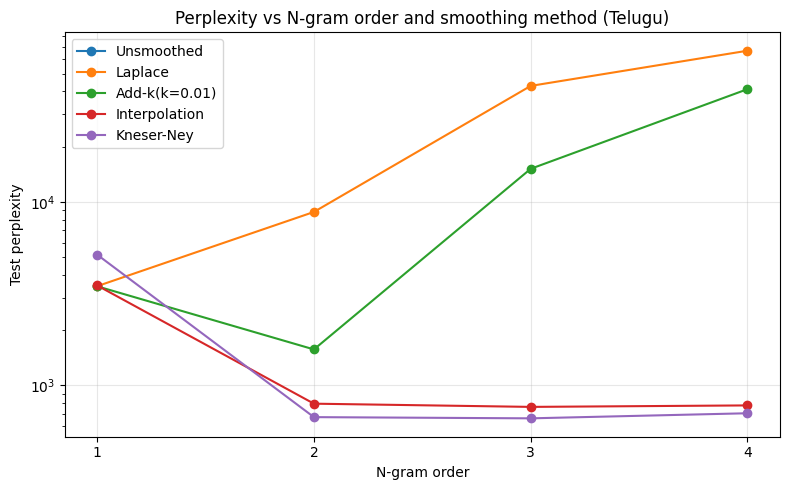


Unsmoothed models typically show 'inf' (or a very high zero_prob_ngram_fraction in the CSV) at higher N — that's the expected, correct result: raw MLE assigns zero probability to any unseen n-gram, and test data will always contain some. This is exactly the failure mode the smoothing methods are meant to fix.

All results saved under: /kaggle/working/indiccorp_experiment


In [24]:
pivot_test = (df_results[df_results.split == "test"]
              .pivot(index="method", columns="N", values="perplexity"))
print("\n=== Test-set perplexity: method x order ===")
print(pivot_test.to_string())
pivot_test.to_csv(os.path.join(OUT_DIR, "lm_perplexity_pivot_test.csv"))

plt.figure(figsize=(8, 5))
for method in df_results.method.unique():
    sub = (df_results[(df_results.method == method) & (df_results.split == "test")]
           .sort_values("N"))
    plotted = sub.replace([np.inf], np.nan)   # keep Unsmoothed's inf out of the line plot
    plt.plot(plotted.N, plotted.perplexity, marker="o", label=method)
plt.xlabel("N-gram order"); plt.ylabel("Test perplexity")
plt.title(f"Perplexity vs N-gram order and smoothing method ({LANGUAGE_NAME})")
plt.yscale("log")
plt.xticks(N_ORDERS)
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "lm_perplexity_comparison.png"))
plt.show()

print(f"\nUnsmoothed models typically show 'inf' (or a very high zero_prob_ngram_fraction "
      f"in the CSV) at higher N — that's the expected, correct result: raw MLE assigns "
      f"zero probability to any unseen n-gram, and test data will always contain some. "
      f"This is exactly the failure mode the smoothing methods are meant to fix.")
print(f"\nAll results saved under: {OUT_DIR}")

---
# PART 3 — Word Embeddings, Clustering, and Nearest-Sentence Retrieval
Reuses the same `train_1000000.txt` / `dev.txt` / `test.txt` from Parts 1 and 2 above. Trains Word2Vec, fastText, and Doc2Vec; K-means clusters the word vectors; represents every dev/test sentence as a vector (via averaged word embeddings and via Doc2Vec) and finds its closest training sentence.

**Note:** one extra install cell below adds `gensim` and `scikit-learn`, which the earlier parts didn't need.

In [25]:
!pip install -q gensim scikit-learn

### Cell 1 — Config

In [26]:
import os, re, json, math, random
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
from tqdm import tqdm

random.seed(42)
np.random.seed(42)

LANG_SPLIT    = "tel_Telu"   # matches the previous assignments
LANGUAGE_NAME = "Telugu"
ISO_CODE      = "te"

DEV_SIZE, TEST_SIZE = 1000, 1000
TRAIN_SIZES = [100_000, 300_000, 500_000, 1_000_000]
MIN_WORDS, MAX_WORDS = 3, 100
MIN_RAW_SENTENCES_NEEDED = max(TRAIN_SIZES) + DEV_SIZE + TEST_SIZE + 50_000
LM_TRAIN_SENTENCES = 1_000_000

OUT_DIR = "/kaggle/working/indiccorp_experiment"
os.makedirs(OUT_DIR, exist_ok=True)

# --- Embedding hyperparameters ---------------------------------------------
VECTOR_SIZE = 100
WINDOW      = 5
MIN_COUNT   = 5        # ignore words rarer than this (same spirit as the LM assignment)
WORKERS     = 4
W2V_EPOCHS  = 5
FT_EPOCHS   = 5
D2V_EPOCHS  = 10        # Doc2Vec generally benefits from a few more passes

NUM_CLUSTERS          = 50   # k for K-means over word vectors
TOP_WORDS_PER_CLUSTER = 20

NN_BATCH_SIZE = 50_000       # batch size for the train-set nearest-neighbor scan

### Cell 2 — Load train/dev/test (reuse if present, else rebuild identically)

In [27]:
train_path = os.path.join(OUT_DIR, f"train_{LM_TRAIN_SENTENCES}.txt")
dev_path   = os.path.join(OUT_DIR, "dev.txt")
test_path  = os.path.join(OUT_DIR, "test.txt")

def read_lines(path):
    with open(path, encoding="utf-8") as f:
        return [l.rstrip("\n") for l in f]

if os.path.exists(train_path) and os.path.exists(dev_path) and os.path.exists(test_path):
    print("Found existing splits on disk — loading them directly.")
    train_sentences = read_lines(train_path)
    dev_sentences   = read_lines(dev_path)
    test_sentences  = read_lines(test_path)
else:
    print("Splits not found in this session — rebuilding from scratch "
          "(same LANG_SPLIT + same seed => identical split to before).")
    from datasets import load_dataset

    def stream_raw_paragraphs(lang_split):
        last_err = None
        for kwargs in (
            dict(path="ai4bharat/IndicCorpV2", name="indiccorp_v2", split=lang_split, streaming=True),
            dict(path="ai4bharat/IndicCorpV2", name="indiccorp_v2", data_dir=f"data/{lang_split}", split="train", streaming=True),
        ):
            try:
                ds = load_dataset(**kwargs)
                for row in ds:
                    text = (row.get("text") or row.get("Text") or next(iter(row.values())) or "").strip()
                    if text:
                        yield text
                return
            except Exception as e:
                last_err = e
        raise RuntimeError(f"Could not stream split '{lang_split}': {last_err}")

    try:
        from indicnlp.tokenize import sentence_tokenize
        INDIC_NLP_AVAILABLE = True
    except ImportError:
        INDIC_NLP_AVAILABLE = False

    _SENT_END_RE = re.compile(r'(?<=[।॥.!?])\s+')

    def split_sentences(paragraph, iso_code=ISO_CODE):
        if INDIC_NLP_AVAILABLE and iso_code:
            try:
                sents = [s.strip() for s in sentence_tokenize.sentence_split(paragraph, lang=iso_code) if s.strip()]
                if sents:
                    return sents
            except Exception:
                pass
        return [s.strip() for s in _SENT_END_RE.split(paragraph) if s.strip()]

    def word_count(s):
        return len(s.split())

    def build_sentence_corpus(lang_split, target_count):
        seen, sentences = set(), []
        pbar = tqdm(total=target_count, desc="Collecting sentences")
        for para in stream_raw_paragraphs(lang_split):
            for sent in split_sentences(para):
                wc = word_count(sent)
                if wc < MIN_WORDS or wc > MAX_WORDS or sent in seen:
                    continue
                seen.add(sent)
                sentences.append(sent)
                pbar.update(1)
                if len(sentences) >= target_count:
                    pbar.close()
                    return sentences
        pbar.close()
        return sentences

    all_sentences = build_sentence_corpus(LANG_SPLIT, MIN_RAW_SENTENCES_NEEDED)
    lengths = np.array([word_count(s) for s in all_sentences])
    BIN_EDGES = [0, 5, 10, 15, 20, 25, 30, 40, 50, 70, 100, 1000]
    bin_ids = np.digitize(lengths, BIN_EDGES)

    def stratified_sample_indices(bin_ids, n_total, exclude=None):
        exclude = exclude or set()
        by_bin = defaultdict(list)
        for idx, b in enumerate(bin_ids):
            if idx not in exclude:
                by_bin[b].append(idx)
        total_pool = sum(len(v) for v in by_bin.values())
        raw_alloc = {b: len(v) / total_pool * n_total for b, v in by_bin.items()}
        alloc = {b: int(math.floor(v)) for b, v in raw_alloc.items()}
        remainder = n_total - sum(alloc.values())
        fracs = sorted(raw_alloc.items(), key=lambda kv: (kv[1] - math.floor(kv[1])), reverse=True)
        i = 0
        while remainder > 0 and i < len(fracs):
            b = fracs[i][0]
            if alloc[b] < len(by_bin[b]):
                alloc[b] += 1
                remainder -= 1
            i += 1
        selected = []
        for b, count in alloc.items():
            pool = by_bin[b]
            selected.extend(random.sample(pool, min(count, len(pool))))
        random.shuffle(selected)
        return set(selected)

    dev_idx  = stratified_sample_indices(bin_ids, DEV_SIZE)
    test_idx = stratified_sample_indices(bin_ids, TEST_SIZE, exclude=dev_idx)
    dev_sentences  = [all_sentences[i] for i in dev_idx]
    test_sentences = [all_sentences[i] for i in test_idx]
    train_pool_idx = [i for i in range(len(all_sentences)) if i not in dev_idx and i not in test_idx]
    train_pool = [all_sentences[i] for i in train_pool_idx]
    random.shuffle(train_pool)
    train_sentences = train_pool[:LM_TRAIN_SENTENCES]

    def save_lines(path, lines):
        with open(path, "w", encoding="utf-8") as f:
            for l in lines:
                f.write(l.replace("\n", " ").strip() + "\n")
    save_lines(dev_path, dev_sentences)
    save_lines(test_path, test_sentences)
    save_lines(train_path, train_sentences)

print(f"Train: {len(train_sentences)} | Dev: {len(dev_sentences)} | Test: {len(test_sentences)}")

Found existing splits on disk — loading them directly.
Train: 1000000 | Dev: 1000 | Test: 1000


### Cell 3 — Tokenize into word lists

In [28]:
def tokenize(sentence):
    return sentence.split()

train_tokens = [tokenize(s) for s in tqdm(train_sentences, desc="Tokenizing train")]
dev_tokens   = [tokenize(s) for s in dev_sentences]
test_tokens  = [tokenize(s) for s in test_sentences]

Tokenizing train: 100%|██████████| 1000000/1000000 [00:05<00:00, 171992.94it/s]


### Cell 4 — Train Word2Vec

In [29]:
# (mirrors https://radimrehurek.com/gensim/auto_examples/tutorials/run_word2vec.html)
from gensim.models import Word2Vec

print("Training Word2Vec ...")
w2v_model = Word2Vec(
    sentences=train_tokens,
    vector_size=VECTOR_SIZE,
    window=WINDOW,
    min_count=MIN_COUNT,
    workers=WORKERS,
    epochs=W2V_EPOCHS,
    sg=0,   # CBOW; set sg=1 for skip-gram if you'd rather compare
)
w2v_model.save(os.path.join(OUT_DIR, "word2vec.model"))
print(f"Word2Vec vocab size: {len(w2v_model.wv)}")

Training Word2Vec ...
Word2Vec vocab size: 138056


### Cell 5 — Train fastText

In [30]:
# (mirrors https://radimrehurek.com/gensim/auto_examples/tutorials/run_fasttext.html)
from gensim.models import FastText

print("Training fastText ...")
ft_model = FastText(
    sentences=train_tokens,
    vector_size=VECTOR_SIZE,
    window=WINDOW,
    min_count=MIN_COUNT,
    workers=WORKERS,
    epochs=FT_EPOCHS,
    sg=0,
)
ft_model.save(os.path.join(OUT_DIR, "fasttext.model"))
print(f"fastText vocab size: {len(ft_model.wv)}")

Training fastText ...
fastText vocab size: 138056


### Cell 6 — Train Doc2Vec

In [31]:
# (mirrors https://radimrehurek.com/gensim/auto_examples/tutorials/run_doc2vec_lee.html)
from gensim.models.doc2vec import Doc2Vec, TaggedDocument

print("Building tagged documents for Doc2Vec ...")
# Integer tags in sentence order -> model.dv.vectors ends up in the same
# order as train_sentences, so we can read it back as one big array later.
tagged_train = [TaggedDocument(words=toks, tags=[i]) for i, toks in enumerate(train_tokens)]

print("Training Doc2Vec ...")
d2v_model = Doc2Vec(
    documents=tagged_train,
    vector_size=VECTOR_SIZE,
    window=WINDOW,
    min_count=MIN_COUNT,
    workers=WORKERS,
    epochs=D2V_EPOCHS,
    dm=1,   # PV-DM, as in the gensim tutorial
)
d2v_model.save(os.path.join(OUT_DIR, "doc2vec.model"))
print(f"Doc2Vec vocab size: {len(d2v_model.wv)} | docvecs: {len(d2v_model.dv)}")

Building tagged documents for Doc2Vec ...
Training Doc2Vec ...
Doc2Vec vocab size: 138056 | docvecs: 1000000


### Cell 7 — K-means clustering of word vectors

In [32]:
from sklearn.cluster import KMeans

print("Running K-means on Word2Vec word vectors ...")
word_vectors = w2v_model.wv.vectors           # shape (vocab_size, VECTOR_SIZE)
vocab_words  = w2v_model.wv.index_to_key      # word for row i

kmeans = KMeans(n_clusters=NUM_CLUSTERS, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(word_vectors)
centroids = kmeans.cluster_centers_

cluster_top_words = {}
for cluster_id in range(NUM_CLUSTERS):
    member_idx = np.where(cluster_labels == cluster_id)[0]
    if len(member_idx) == 0:
        cluster_top_words[cluster_id] = []
        continue
    member_vecs = word_vectors[member_idx]
    dists = np.linalg.norm(member_vecs - centroids[cluster_id], axis=1)
    order = np.argsort(dists)[:TOP_WORDS_PER_CLUSTER]
    cluster_top_words[cluster_id] = [vocab_words[member_idx[j]] for j in order]

with open(os.path.join(OUT_DIR, "kmeans_clusters.json"), "w", encoding="utf-8") as f:
    json.dump({str(k): v for k, v in cluster_top_words.items()}, f, ensure_ascii=False, indent=2)

for cluster_id in range(min(10, NUM_CLUSTERS)):   # print a sample of clusters
    print(f"Cluster {cluster_id} ({len(cluster_top_words[cluster_id])} words shown): "
          f"{cluster_top_words[cluster_id]}")
print(f"\nAll {NUM_CLUSTERS} clusters saved to kmeans_clusters.json")

Running K-means on Word2Vec word vectors ...
Cluster 0 (20 words shown): ['దేవుడు:', 'కాబోలు', 'నేనెప్పుడూ', 'మనిషిలా', 'చావును', 'యిష్టం', 'నాన్నా.', 'అనుకుంటాం.', 'సేపూ', 'మీకేం', 'ధర్మము', 'ఇవేమీ', 'నవ్వింది.', 'వాళ్ళంతా', 'దేన్నీ', '‘ఇప్పుడు', 'అంటుంటారు', 'భగవంతుడికి', 'పగలబడి', 'అందరిదీ']
Cluster 1 (20 words shown): ['దేవరాపల్లిలోను,', 'వరికుంటపాడు', 'ఓజిలి', 'ముంచింగిపుట్టులోను,', 'విజయవాడలోను,', 'రాజాంలోను,', 'వెంకటగిరిలోను,', 'కొత్తకోటలోను,', '660,', 'గుర్ల', 'నందిపేట్', '531030.', 'ఆత్మకూరులోను,', 'డుంబ్రిగూడ', '124.', '56.', 'నరసన్నపేటలోను,', 'మంచిర్యాలలోను,', '643', 'కోమటిపల్లిలోనూ']
Cluster 2 (20 words shown): ['సీబీఐకి', 'పిటిషన్\u200c', 'ఆదేశించిన', 'ఆదేశం', 'హైకోర్టుకు', 'బెయిల్\u200c', 'సీఐడీ', 'సమర్పించాలని', 'ఎస్ఈసీ', 'పిటిషన్\u200cపై', 'దర్యాప్తును', 'తీర్పుపై', 'కస్టడీకి', 'అప్పగించాలని', 'సిట్', 'కోర్టు.', 'సుప్రీంకోర్టులో', 'అఫిడవిట్', 'ఆదేశాలను', 'వెలువరించింది.']
Cluster 3 (20 words shown): ['వాళ్ళని', 'నేనూ', 'ఇంక', 'నీతో', 'ఊరికే', 'నాకే', 'విప్పి', 'అమ్మకు',

### Cell 8 — Sentence vectors: averaged word embeddings + Doc2Vec

In [33]:
def average_vector(tokens, kv):
    """Mean of the word vectors for tokens present in `kv`'s vocab; zero vector if none found."""
    vecs = [kv[w] for w in tokens if w in kv]
    if not vecs:
        return np.zeros(kv.vector_size, dtype=np.float32)
    return np.mean(vecs, axis=0).astype(np.float32)

print("Building averaged-Word2Vec sentence vectors ...")
train_vecs_w2v = np.vstack([average_vector(t, w2v_model.wv) for t in tqdm(train_tokens)])
dev_vecs_w2v   = np.vstack([average_vector(t, w2v_model.wv) for t in dev_tokens])
test_vecs_w2v  = np.vstack([average_vector(t, w2v_model.wv) for t in test_tokens])

print("Building averaged-fastText sentence vectors (fastText also covers OOV words via subwords) ...")
train_vecs_ft = np.vstack([average_vector(t, ft_model.wv) for t in tqdm(train_tokens)])
dev_vecs_ft   = np.vstack([average_vector(t, ft_model.wv) for t in dev_tokens])
test_vecs_ft  = np.vstack([average_vector(t, ft_model.wv) for t in test_tokens])

print("Reading Doc2Vec training vectors (already learned during training) ...")
train_vecs_d2v = np.vstack([d2v_model.dv[i] for i in range(len(train_tokens))]).astype(np.float32)

print("Inferring Doc2Vec vectors for dev/test (unseen at training time) ...")
dev_vecs_d2v  = np.vstack([d2v_model.infer_vector(t, epochs=D2V_EPOCHS) for t in tqdm(dev_tokens)]).astype(np.float32)
test_vecs_d2v = np.vstack([d2v_model.infer_vector(t, epochs=D2V_EPOCHS) for t in tqdm(test_tokens)]).astype(np.float32)

np.save(os.path.join(OUT_DIR, "train_vecs_w2v.npy"), train_vecs_w2v)
np.save(os.path.join(OUT_DIR, "train_vecs_ft.npy"),  train_vecs_ft)
np.save(os.path.join(OUT_DIR, "train_vecs_d2v.npy"), train_vecs_d2v)

Building averaged-Word2Vec sentence vectors ...


100%|██████████| 1000000/1000000 [00:48<00:00, 20682.64it/s]


Building averaged-fastText sentence vectors (fastText also covers OOV words via subwords) ...


100%|██████████| 1000000/1000000 [01:53<00:00, 8805.73it/s]


Reading Doc2Vec training vectors (already learned during training) ...
Inferring Doc2Vec vectors for dev/test (unseen at training time) ...


100%|██████████| 1000/1000 [00:00<00:00, 1738.36it/s]


### Cell 9 — Nearest training sentence for every dev/test sentence (per method)

In [34]:
def batched_nearest_neighbor(query_vecs, train_vecs, batch_size=NN_BATCH_SIZE):
    """
    Cosine-similarity nearest neighbor of each query vector against all rows
    of train_vecs, without ever materializing the full (queries x train)
    similarity matrix at once.
    """
    def normalize(m):
        norms = np.linalg.norm(m, axis=1, keepdims=True)
        norms[norms == 0] = 1.0
        return m / norms

    q = normalize(query_vecs.astype(np.float32))
    n_queries = q.shape[0]
    best_sim = np.full(n_queries, -np.inf, dtype=np.float32)
    best_idx = np.zeros(n_queries, dtype=np.int64)

    for start in tqdm(range(0, train_vecs.shape[0], batch_size), desc="Scanning train set"):
        batch = normalize(train_vecs[start:start + batch_size].astype(np.float32))
        sims = q @ batch.T                       # (n_queries, batch_size)
        batch_best_val = sims.max(axis=1)
        batch_best_idx = sims.argmax(axis=1) + start
        improve = batch_best_val > best_sim
        best_sim[improve] = batch_best_val[improve]
        best_idx[improve] = batch_best_idx[improve]

    return best_idx, best_sim

results_rows = []

def run_nn_and_collect(method_name, query_vecs, query_sentences, split_name, train_vecs):
    idx, sim = batched_nearest_neighbor(query_vecs, train_vecs)
    for i in range(len(query_sentences)):
        results_rows.append({
            "method": method_name,
            "split": split_name,
            "query_index": i,
            "query_sentence": query_sentences[i],
            "closest_train_index": int(idx[i]),
            "closest_train_sentence": train_sentences[idx[i]],
            "cosine_similarity": float(sim[i]),
        })

print("\n=== Nearest-neighbor search: averaged Word2Vec ===")
run_nn_and_collect("avg_word2vec", dev_vecs_w2v,  dev_sentences,  "dev",  train_vecs_w2v)
run_nn_and_collect("avg_word2vec", test_vecs_w2v, test_sentences, "test", train_vecs_w2v)

print("\n=== Nearest-neighbor search: averaged fastText ===")
run_nn_and_collect("avg_fasttext", dev_vecs_ft,  dev_sentences,  "dev",  train_vecs_ft)
run_nn_and_collect("avg_fasttext", test_vecs_ft, test_sentences, "test", train_vecs_ft)

print("\n=== Nearest-neighbor search: Doc2Vec ===")
run_nn_and_collect("doc2vec", dev_vecs_d2v,  dev_sentences,  "dev",  train_vecs_d2v)
run_nn_and_collect("doc2vec", test_vecs_d2v, test_sentences, "test", train_vecs_d2v)

df_nn = pd.DataFrame(results_rows)
df_nn.to_csv(os.path.join(OUT_DIR, "nearest_sentence_results.csv"), index=False)

print("\nSample results:")
for method in df_nn.method.unique():
    row = df_nn[(df_nn.method == method) & (df_nn.split == "dev")].iloc[0]
    print(f"\n[{method}] dev sentence #0")
    print(f"  Query : {row.query_sentence}")
    print(f"  Match : {row.closest_train_sentence}")
    print(f"  Cosine similarity: {row.cosine_similarity:.4f}")

print(f"\nMean cosine similarity by method/split:")
print(df_nn.groupby(["method", "split"])["cosine_similarity"].mean().to_string())

print(f"\nAll results saved under: {OUT_DIR}")


=== Nearest-neighbor search: averaged Word2Vec ===


Scanning train set: 100%|██████████| 20/20 [00:03<00:00,  5.49it/s]



=== Nearest-neighbor search: averaged fastText ===


Scanning train set: 100%|██████████| 20/20 [00:03<00:00,  5.62it/s]



=== Nearest-neighbor search: Doc2Vec ===


Scanning train set: 100%|██████████| 20/20 [00:03<00:00,  5.59it/s]



Sample results:

[avg_word2vec] dev sentence #0
  Query : తాజాగా ఇజిన్‌ అనే కౌంటీలో కరోనా డెల్టా వేరియంట్‌ ప్రబలింది.
  Match : అందులోనూ కరోనా కొత్త రకం స్ట్రైయిన్ అనే వైరస్ విజృంభిస్తుండటంతో ప్రపంచదేశాలు అప్రమత్తమయ్యాయి.
  Cosine similarity: 0.8980

[avg_fasttext] dev sentence #0
  Query : తాజాగా ఇజిన్‌ అనే కౌంటీలో కరోనా డెల్టా వేరియంట్‌ ప్రబలింది.
  Match : ఇప్పటికే అమెరికా ఫైజర్ అనే కరోనా నిర్మూలనకు టీకాను తయారుచేసింది.
  Cosine similarity: 0.8526

[doc2vec] dev sentence #0
  Query : తాజాగా ఇజిన్‌ అనే కౌంటీలో కరోనా డెల్టా వేరియంట్‌ ప్రబలింది.
  Match : టోలోను-ఒబ్బి అనే జీబూ పశువుల కుస్తీ, అనేక ప్రాంతాలలో అభ్యసించబడుతుంది.
  Cosine similarity: 0.8397

Mean cosine similarity by method/split:
method        split
avg_fasttext  dev      0.903974
              test     0.903375
avg_word2vec  dev      0.894983
              test     0.894729
doc2vec       dev      0.729502
              test     0.736985

All results saved under: /kaggle/working/indiccorp_experiment
